In [ ]:
####### Making the three versions of the ttls that each segement the data by one of the three questions
#q1_slider.response: emotion perception
#q2_slider.response: emotion
#q3_slider.response: empathy


Processing file: \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl\01_modified_events.txt
File columns: ['number', 'type', 'edftype', 'latency', 'duration', 'urevent', 'q1_slider.response', 'q2_slider.response', 'q3_slider.response', 'participant']
Processing file: \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl\02_modified_events.txt
File columns: ['number', 'type', 'edftype', 'latency', 'duration', 'urevent', 'q1_slider.response', 'q2_slider.response', 'q3_slider.response', 'participant']
Processing file: \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl\03_modified_events.txt
File columns: ['number', 'type', 'edftype', 'latency', 'duration', 'urevent', 'q1_slider.response', 'q2_slider.response', 'q3_slider.response', 'participant']
Processing file: \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\ne

File columns: ['number', 'type', 'edftype', 'latency', 'duration', 'urevent', 'q1_slider.response', 'q2_slider.response', 'q3_slider.response', 'participant']
Processing file: \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl\39_modified_events.txt
File columns: ['number', 'type', 'edftype', 'latency', 'duration', 'urevent', 'q1_slider.response', 'q2_slider.response', 'q3_slider.response', 'participant']
Processing file: \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl\40_modified_events.txt
File columns: ['number', 'type', 'edftype', 'latency', 'duration', 'urevent', 'q1_slider.response', 'q2_slider.response', 'q3_slider.response', 'participant']
Processing file: \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl\41_modified_events.txt
File columns: ['number', 'type', 'edftype', 'latency', 'duration', 'urevent', 'q1_slider.response', 'q2_slide

C:\Users\tonglin\AppData\Local\Temp\ipykernel_15956\225570874.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([all_data[all_data['participant'] == pid][column].dropna() for pid in participant_ids],


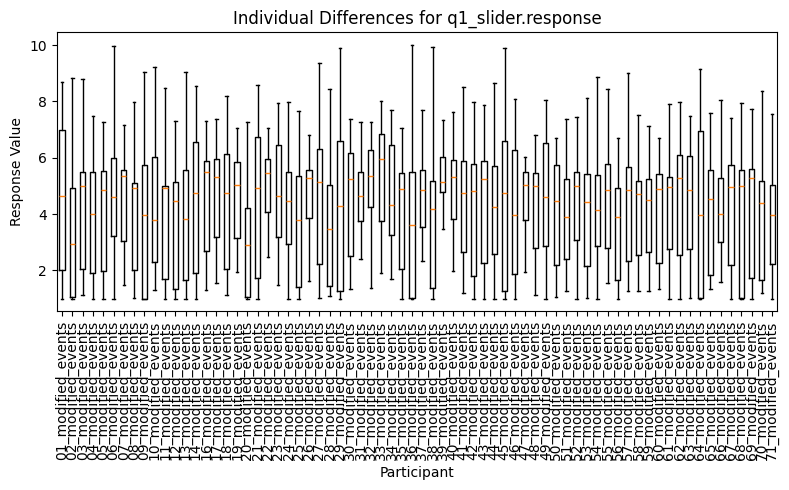

C:\Users\tonglin\AppData\Local\Temp\ipykernel_15956\225570874.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([all_data[all_data['participant'] == pid][column].dropna() for pid in participant_ids],


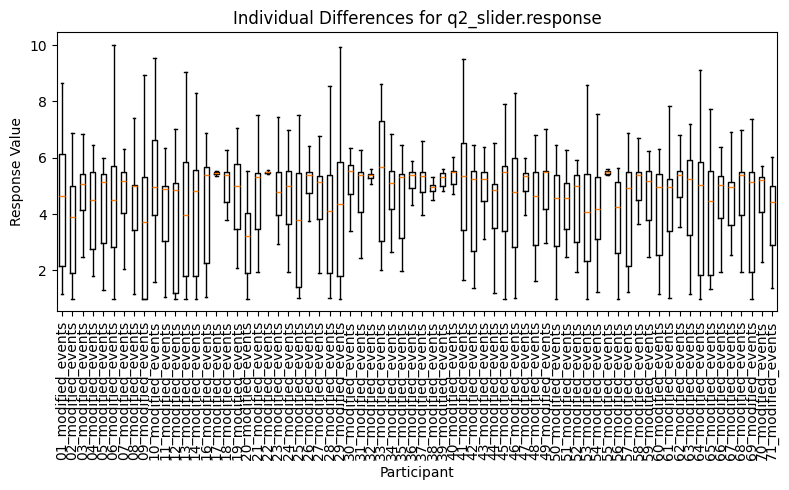

C:\Users\tonglin\AppData\Local\Temp\ipykernel_15956\225570874.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([all_data[all_data['participant'] == pid][column].dropna() for pid in participant_ids],


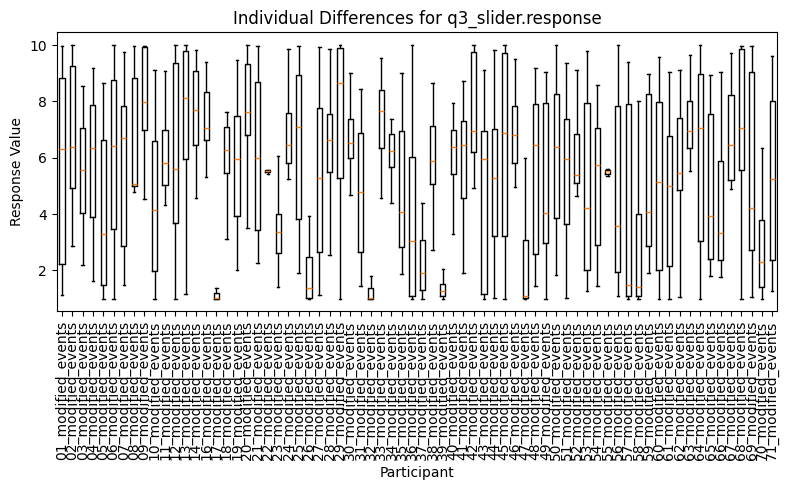

Selected summary statistics:
         q1_slider.response  q2_slider.response  q3_slider.response
mean              4.291328            4.546218            5.429679
min               1.000000            1.000000            1.000000
max              10.000000           10.000000           10.000000
median            4.687012            5.016602            5.587891


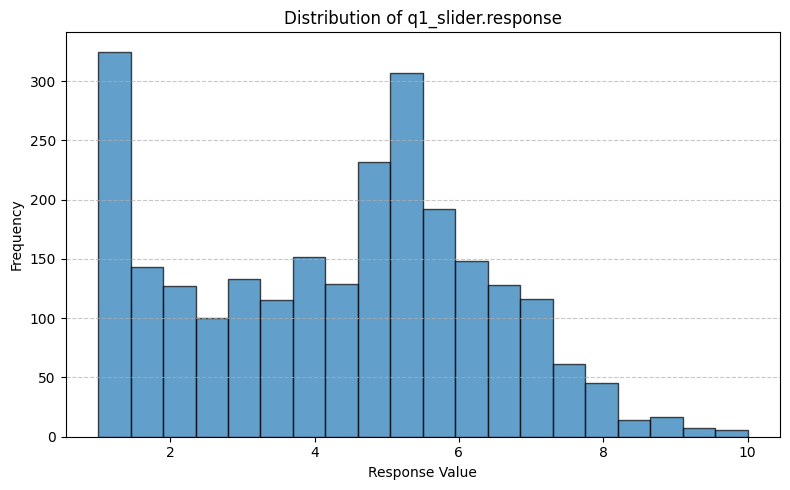

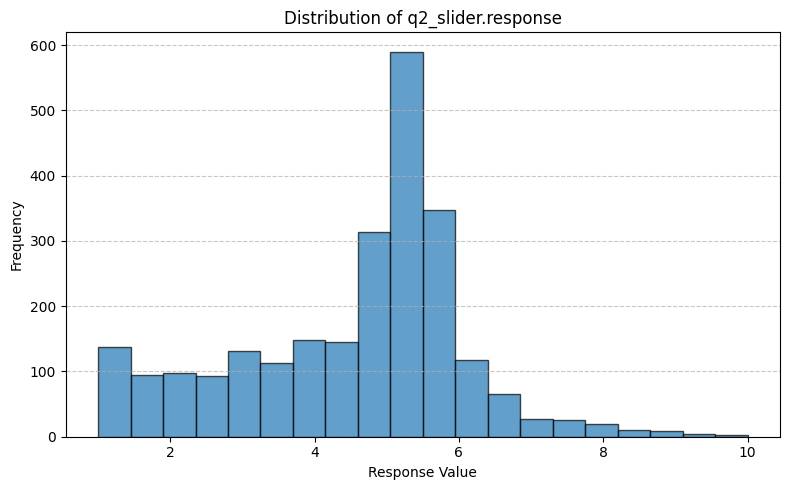

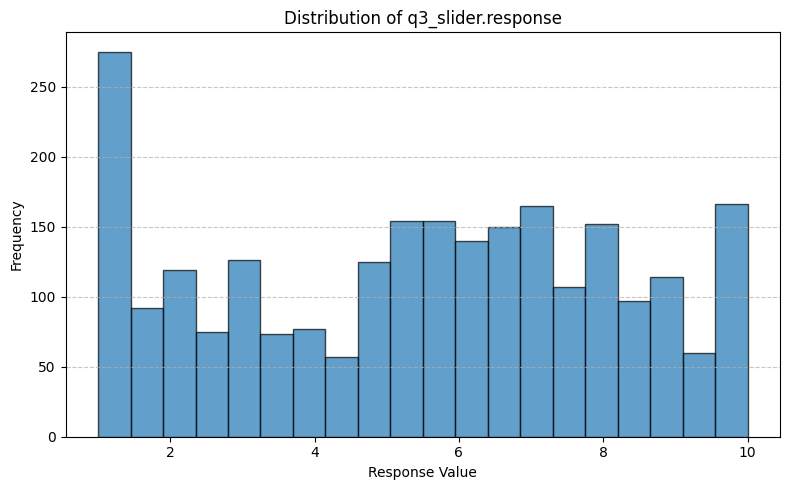

In [9]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

######################## Checking the stats of the ratings to see trends from mean, median etc. ###############
# Define the folder containing the txt files
folder_path = r"\\......\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl"
output_folder = r"\\......\Tong_computer\Dissertation Study 2\summary statistics"
os.makedirs(output_folder, exist_ok=True)

# Initialize an empty DataFrame to store all data
all_data = pd.DataFrame()

# Read all txt files in the folder
file_count = 0
participant_ids = []
for file_path in glob.glob(os.path.join(folder_path, "*.txt")):
    file_count += 1
    participant_id = os.path.basename(file_path).split('.')[0]  # Extract participant ID from file name
    participant_ids.append(participant_id)
    print(f"Processing file: {file_path}")
    try:
        # Read the file as a tab-delimited table
        data = pd.read_csv(file_path, delimiter='\t')
        data['participant'] = participant_id  # Add participant ID column
        print(f"File columns: {list(data.columns)}")

        # Check if required columns exist in the file
        if all(col in data.columns for col in ["q1_slider.response", "q2_slider.response", "q3_slider.response"]):
            all_data = pd.concat([all_data, data[["q1_slider.response", "q2_slider.response", "q3_slider.response", "participant"]]], axis=0)
        else:
            print(f"Missing required columns in file: {file_path}")
    except Exception as e:
        print(f"Error reading file {file_path}: {e}")

print(f"Total files processed: {file_count}")
print(f"Total rows extracted: {len(all_data)}")

# Ensure all_data contains only numeric values for the response columns
for column in ["q1_slider.response", "q2_slider.response", "q3_slider.response"]:
    if column in all_data.columns:
        print(f"Cleaning column: {column}")
        all_data[column] = pd.to_numeric(all_data[column], errors='coerce')  # Convert to numeric, set errors to NaN
        print(f"After cleaning, {column} has {all_data[column].isna().sum()} NaN values")

# Drop rows where all response columns are NaN
all_data.dropna(subset=["q1_slider.response", "q2_slider.response", "q3_slider.response"], how='all', inplace=True)

# Check if the DataFrame is still non-empty
if all_data.empty:
    print("No valid numeric data available after cleaning.")
else:
    # Compute summary statistics
    summary_stats = all_data.describe()
    print("Summary statistics:\n", summary_stats)

    # Save summary statistics to a CSV file
    summary_stats.to_csv(os.path.join(output_folder, "summary_statistics.csv"))

    # Compute and plot individual differences
    individual_stats = all_data.groupby('participant').mean()
    print("Individual differences statistics:\n", individual_stats)
    individual_stats.to_csv(os.path.join(output_folder, "individual_statistics.csv"))

    for column in ["q1_slider.response", "q2_slider.response", "q3_slider.response"]:
        if column in all_data.columns and not all_data[column].isnull().all():
            plt.figure(figsize=(8, 5))
            plt.boxplot([all_data[all_data['participant'] == pid][column].dropna() for pid in participant_ids],
                        labels=participant_ids, showfliers=False)
            plt.title(f"Individual Differences for {column}")
            plt.xlabel("Participant")
            plt.ylabel("Response Value")
            plt.xticks(rotation=90)
            plt.tight_layout()
            plt.savefig(os.path.join(output_folder, f"individual_differences_{column}.png"))
            plt.show()

    # Check if specific statistics are available
    if not {"mean", "min", "max", "50%"}.issubset(summary_stats.index):
        print("Expected statistics (mean, min, max, median) are missing. Please check the input data.")
    else:
        # Rename "50%" to "median" for clarity
        summary_stats = summary_stats.loc[["mean", "min", "max", "50%"]]
        summary_stats.rename(index={"50%": "median"}, inplace=True)
        print("Selected summary statistics:\n", summary_stats)

    # Plot distribution figures
    for column in ["q1_slider.response", "q2_slider.response", "q3_slider.response"]:
        if column in all_data.columns and not all_data[column].isnull().all():
            plt.figure(figsize=(8, 5))
            plt.hist(all_data[column].dropna(), bins=20, edgecolor='black', alpha=0.7)
            plt.title(f"Distribution of {column}")
            plt.xlabel("Response Value")
            plt.ylabel("Frequency")
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            plt.tight_layout()
            plt.savefig(os.path.join(output_folder, f"distribution_{column}.png"))
            plt.show()
        else:
            print(f"No valid data available for {column}, skipping plot.")


In [24]:
import os
import pandas as pd

############################# Splitting for the 3 questions ##########################################
# Define paths
input_folder = r"\\......\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl"
output_folders = {
    "q1": r"\\......\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl\ep_ttls",
    "q2": r"\\......\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl\emotion_ttl",
    "q3": r"\\......\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl\empathy_ttl"
}

# Ensure output directories exist
for folder in output_folders.values():
    os.makedirs(folder, exist_ok=True)

# Define thresholds for each query
thresholds = {"q1": 4.687, "q2": 5.016, "q3": 5.58}

# Function to process files
def process_file(file_path, query, output_folder, total_none_counter):
    df = pd.read_csv(file_path, delimiter='\t')  # Adjust delimiter if needed
    
    column_name = f"{query}_slider.response"
    if column_name in df.columns:
        type_column = df[column_name].astype(str).str.strip().copy()
        type_column.loc[0] = "long_happy"
        type_column.loc[1] = "long_sad"
        
        none_count = 0  # Counter for "None" values in this file
        threshold = thresholds[query]  # Get the appropriate threshold
        
        for i in range(2, len(df)):
            original_value = type_column.at[i]
            if original_value in ["None", "none"]:
                none_count += 1
                # Look up the corresponding value in "type" column
                corresponding_type = str(df.loc[i, "type"]).strip().lower()
                if "," in corresponding_type:
                    type_column.at[i] = corresponding_type.split(",")[0]
                else:
                    type_column.at[i] = corresponding_type
                continue
            try:
                # Convert to float if possible, handle invalid values
                value = pd.to_numeric(original_value, errors='coerce')
                if pd.notnull(value):
                    if query in ["q1", "q2"]:
                        if 1 <= value <= threshold:
                            type_column.at[i] = "emotional"
                        elif threshold < value <= 10:
                            type_column.at[i] = "neutral"
                    elif query == "q3":
                        if 1 <= value <= threshold:
                            type_column.at[i] = "neutral"
                        elif threshold < value <= 10:
                            type_column.at[i] = "emotional"
                else:
                    print(f"Non-numeric value at row {i}: {original_value} (type: {type(original_value)})")
                    type_column.at[i] = None
            except ValueError:
                print(f"Error converting value at row {i}: {original_value} (type: {type(original_value)})")
                type_column.at[i] = None  # Handle unexpected conversion errors
        
        # Check for invalid values in the type column
        valid_values = {"long_happy", "long_sad", "emotional", "neutral", "None"}
        for idx, value in type_column.items():
            if value not in valid_values:
                print(f"Invalid value in 'type' column at row {idx}: {value} (type: {type(value)})")
        
        print(f"Total 'None' values in {file_path}: {none_count}")
        total_none_counter[0] += none_count
        
        df["type"] = type_column  # Replace type column without changing the original query column
        
        # Drop unnecessary columns
        columns_to_drop = ["q1_slider.response", "q2_slider.response", "q3_slider.response"]
        df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])
        
        # Save modified file
        new_filename = os.path.basename(file_path).replace(".txt", f"_{query}.txt")
        output_path = os.path.join(output_folder, new_filename)
        df.to_csv(output_path, sep='\t', index=False)
        print(f"Processed: {new_filename}")

# Total counter for all "None" values across all files
total_none_counter = [0]

# Process all files in the input folder
for file in os.listdir(input_folder):
    file_path = os.path.join(input_folder, file)
    if file.endswith(".txt"):
        for query, output_folder in output_folders.items():
            process_file(file_path, query, output_folder, total_none_counter)

print(f"Total 'None' values across all files: {total_none_counter[0]}")


Total 'None' values in \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl\01_modified_events.txt: 0
Processed: 01_modified_events_q1.txt
Total 'None' values in \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl\01_modified_events.txt: 0
Processed: 01_modified_events_q2.txt
Total 'None' values in \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl\01_modified_events.txt: 0
Processed: 01_modified_events_q3.txt
Total 'None' values in \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl\02_modified_events.txt: 2
Processed: 02_modified_events_q1.txt
Total 'None' values in \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl\02_modified_events.txt: 2
Processed: 02_modified_events_q2.txt
Total 'None' values in \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertati

Total 'None' values in \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl\17_modified_events.txt: 0
Processed: 17_modified_events_q1.txt
Total 'None' values in \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl\17_modified_events.txt: 0
Processed: 17_modified_events_q2.txt
Total 'None' values in \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl\17_modified_events.txt: 2
Processed: 17_modified_events_q3.txt
Total 'None' values in \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl\18_modified_events.txt: 0
Processed: 18_modified_events_q1.txt
Total 'None' values in \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl\18_modified_events.txt: 0
Processed: 18_modified_events_q2.txt
Total 'None' values in \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertati

Processed: 32_modified_events_q3.txt
Total 'None' values in \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl\33_modified_events.txt: 1
Processed: 33_modified_events_q1.txt
Total 'None' values in \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl\33_modified_events.txt: 1
Processed: 33_modified_events_q2.txt
Total 'None' values in \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl\33_modified_events.txt: 1
Processed: 33_modified_events_q3.txt
Total 'None' values in \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl\34_modified_events.txt: 0
Processed: 34_modified_events_q1.txt
Total 'None' values in \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl\34_modified_events.txt: 0
Processed: 34_modified_events_q2.txt
Total 'None' values in \\files.brandeis.edu

Processed: 47_modified_events_q3.txt
Total 'None' values in \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl\48_modified_events.txt: 2
Processed: 48_modified_events_q1.txt
Total 'None' values in \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl\48_modified_events.txt: 1
Processed: 48_modified_events_q2.txt
Total 'None' values in \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl\48_modified_events.txt: 2
Processed: 48_modified_events_q3.txt
Total 'None' values in \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl\49_modified_events.txt: 0
Processed: 49_modified_events_q1.txt
Total 'None' values in \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl\49_modified_events.txt: 0
Processed: 49_modified_events_q2.txt
Total 'None' values in \\files.brandeis.edu

Processed: 65_modified_events_q3.txt
Total 'None' values in \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl\66_modified_events.txt: 0
Processed: 66_modified_events_q1.txt
Total 'None' values in \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl\66_modified_events.txt: 0
Processed: 66_modified_events_q2.txt
Total 'None' values in \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl\66_modified_events.txt: 0
Processed: 66_modified_events_q3.txt
Total 'None' values in \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl\67_modified_events.txt: 1
Processed: 67_modified_events_q1.txt
Total 'None' values in \\files.brandeis.edu\gutsell-lab\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl\67_modified_events.txt: 1
Processed: 67_modified_events_q2.txt
Total 'None' values in \\files.brandeis.edu

In [1]:
########################### Making the 4th type of splitting ##############################
import os
import pandas as pd

# Define input and output directories
input_folder = r"\\......\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl"
output_folder = r"\\......\Tong_computer\Dissertation Study 2\EEG data\ttl_from_set\new_ttl\video_type_ttl"

# Ensure output directory exists
os.makedirs(output_folder, exist_ok=True)

# Loop through all files in the input folder
for filename in os.listdir(input_folder):
    if filename.endswith(".txt"):  # Process only text files
        input_path = os.path.join(input_folder, filename)
        
        # Read the file
        df = pd.read_csv(input_path, delimiter="\t", dtype=str)  # Keep original formatting

        # Modify 'type' column by keeping only the part before the comma
        if 'type' in df.columns:
            df['type'] = df['type'].apply(lambda x: x.split(',')[0] if pd.notna(x) else x)
            
            # Modify specific elements
            df.loc[0, 'type'] = "long_happy"
            df.loc[1, 'type'] = "long_sad"

        # Generate new filename
        new_filename = filename.replace("_modified_events.txt", "_modified_events_q4.txt")
        output_path = os.path.join(output_folder, new_filename)

        # Drop unnecessary columns
        columns_to_drop = ["q1_slider.response", "q2_slider.response", "q3_slider.response"]
        df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

        # Save the modified file
        df.to_csv(output_path, sep="\t", index=False)

print("Processing complete. Modified files saved in the output folder.")


Processing complete. Modified files saved in the output folder.
